# EC3 — Land Use / Land Cover maps of Bangladesh and Dhaka district

Part of the **Mark 15** open-source mapping portfolio.

- **Map 1:** Bangladesh LULC (ESA WorldCover 2021, 10 m), single panel
- **Map 2:** three panels: (a) Bangladesh with Dhaka Division highlighted, (b) Dhaka Division with Dhaka district highlighted, (c) Dhaka district LULC at full 10 m

**How to run:** put the input files in the folders listed in Cell 1, then use *Kernel → Restart & Run All* from the repo folder. Map 1 needs about 2 minutes for the pass over all 3.4 billion pixels; both maps need internet for the basemap tiles.


In [2]:
# Cell 1: Setup - imports, relative paths, style
import os, glob, time
from pathlib import Path

import numpy as np
import rasterio
from rasterio.features import geometry_mask
from rasterio.merge import merge
from rasterio.transform import from_origin
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, Patch, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pyproj import Geod
from scipy.ndimage import gaussian_filter

# --- Paths (relative: run this notebook from the repo folder) ---
LULC_DIR         = Path("data/lulc")
gadm_path        = Path("data/boundaries/Bangladesh_Country_Boundary.gpkg")
dhaka_path       = Path("data/boundaries/dhaka_district.gpkg")
NORTH_ARROW_FILE = Path("assets/north_arrow.png")
OUT_DIR          = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

lulc_files = sorted(glob.glob(str(LULC_DIR / "LULC_ESA_WorldCover_Bangladesh*.tif")))

# --- Check that everything is in place ---
missing = [str(p) for p in (gadm_path, dhaka_path, NORTH_ARROW_FILE) if not p.exists()]
if not lulc_files:
    missing.append(str(LULC_DIR / "LULC_ESA_WorldCover_Bangladesh*.tif") + "   (one or more tiles)")
if missing:
    raise FileNotFoundError(
        "Missing input files. Expected (relative to this notebook):\n  " + "\n  ".join(missing) +
        "\nSee data/lulc/README.md for where to get the WorldCover tiles.")

print("WorldCover tiles found:", len(lulc_files))
for f in lulc_files:
    print("  ", os.path.basename(f), "-", round(os.path.getsize(f) / 1e6, 1), "MB")

# --- Style ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Georgia", "Times New Roman", "DejaVu Serif"]
deg_lon = ticker.FuncFormatter(lambda x, _: f"{x:.1f}\u00b0E")
deg_lat = ticker.FuncFormatter(lambda y, _: f"{y:.1f}\u00b0N")
halo = [pe.withStroke(linewidth=2.5, foreground="white")]      # keeps text readable on the basemap


WorldCover tiles found: 2
   LULC_ESA_WorldCover_Bangladesh-0000000000-0000000000.tif - 99.2 MB
   LULC_ESA_WorldCover_Bangladesh-0000065536-0000000000.tif - 0.1 MB


In [4]:
# Cell 2: Class table, colours and helper functions

# --- ESA WorldCover classes present in the data: value -> (name, colour) ---
# (values 70 snow/ice and 100 moss/lichen do not occur in Bangladesh)
LULC_CLASSES = {
    10: ("Tree cover",               "#1B5E20"),
    20: ("Shrubland",                "#6A9E3F"),
    30: ("Grassland",                "#A8C840"),
    40: ("Cropland",                 "#E6C200"),
    50: ("Built-up",                 "#7B1FA2"),
    60: ("Bare / sparse vegetation", "#C4A882"),
    80: ("Permanent water bodies",   "#1A6BB5"),
    90: ("Herbaceous wetland",       "#009688"),
    95: ("Mangroves",                "#004D40"),
}
class_ids = list(LULC_CLASSES)

# Lookup table: class value -> RGBA colour (0 = no data = transparent)
LUT = np.zeros((256, 4), dtype=np.uint8)
for v, (_, hex_col) in LULC_CLASSES.items():
    LUT[v] = (*(int(hex_col[i:i + 2], 16) for i in (1, 3, 5)), 255)


# ---------- Helpers used by Map 1 ----------
def style_map_axis(ax):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    ax.set_xticks(np.arange(np.ceil(x0 * 2) / 2, x1, 0.5))
    ax.set_yticks(np.arange(np.ceil(y0 * 2) / 2, y1, 0.5))
    ax.xaxis.set_major_formatter(deg_lon); ax.yaxis.set_major_formatter(deg_lat)
    ax.grid(True, linestyle=":", alpha=0.6, color="black", linewidth=0.5, zorder=1)
    ax.tick_params(axis="x", direction="in", length=6, labelsize=9,
                   bottom=True, top=True, labelbottom=True, labeltop=True)
    ax.tick_params(axis="y", direction="in", length=6, labelsize=9,
                   left=True, right=True, labelleft=True, labelright=True, labelrotation=90)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_verticalalignment("center"); tick.label2.set_verticalalignment("center")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

def add_scale_bar_km(ax, lon0, lat, total_km=100, n_seg=2):
    """Two-tone scale bar. Length comes from real geodesic distance, not degrees."""
    geod = Geod(ellps="WGS84")
    seg_km = total_km / n_seg
    lons = [lon0] + [geod.fwd(lon0, lat, 90, k * seg_km * 1000)[0] for k in range(1, n_seg + 1)]
    h = 0.06
    for i in range(n_seg):
        ax.add_patch(Rectangle((lons[i], lat), lons[i + 1] - lons[i], h,
                               facecolor="black" if i % 2 == 0 else "white",
                               edgecolor="black", linewidth=0.8, zorder=10))
    for i, lon in enumerate(lons):
        ax.text(lon, lat + h + 0.03, f"{i * seg_km:g}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", zorder=10, path_effects=halo)
    ax.text(lons[-1] + 0.06, lat + h / 2, "km", ha="left", va="center",
            fontsize=9, fontweight="bold", zorder=10, path_effects=halo)


# ---------- Helpers used by Map 2 ----------
def limits(gdf, w, e, s, n):
    """Panel limits (degrees): the data bounds plus west, east, south, north padding."""
    x0, y0, x1, y1 = gdf.total_bounds
    return (x0 - w, x1 + e), (y0 - s, y1 + n)

def wh_ratio(xl, yl):
    """Width/height of a panel with the lon/lat stretch correction."""
    lat = (yl[0] + yl[1]) / 2
    return (xl[1] - xl[0]) * np.cos(np.radians(lat)) / (yl[1] - yl[0])

def style_axis(ax, step):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    ax.set_xticks(np.arange(np.ceil(x0 / step) * step, x1, step))
    ax.set_yticks(np.arange(np.ceil(y0 / step) * step, y1, step))
    ax.xaxis.set_major_formatter(deg_lon); ax.yaxis.set_major_formatter(deg_lat)
    ax.grid(True, linestyle=":", alpha=0.6, color="black", linewidth=0.5, zorder=1)
    ax.tick_params(axis="x", direction="in", length=6, labelsize=9,
                   bottom=True, top=True, labelbottom=True, labeltop=False)
    ax.tick_params(axis="y", direction="in", length=6, labelsize=9,
                   left=True, right=True, labelleft=True, labelright=False, labelrotation=90)
    for t in ax.yaxis.get_major_ticks():
        t.label1.set_verticalalignment("center")
    for sp in ax.spines.values():
        sp.set_linewidth(1.5)

def scale_bar(ax, lon0, lat, total_km, n_seg=2):
    """Two-tone geodesic scale bar; bar height scales with the panel."""
    geod = Geod(ellps="WGS84")
    y0, y1 = ax.get_ylim()
    h = 0.012 * (y1 - y0)
    seg = total_km / n_seg
    lons = [lon0] + [geod.fwd(lon0, lat, 90, k * seg * 1000)[0] for k in range(1, n_seg + 1)]
    for i in range(n_seg):
        ax.add_patch(Rectangle((lons[i], lat), lons[i + 1] - lons[i], h,
                               facecolor="black" if i % 2 == 0 else "white",
                               edgecolor="black", linewidth=0.8, zorder=10))
    for i, lon in enumerate(lons):
        ax.text(lon, lat + 1.5 * h, f"{i * seg:g}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", zorder=10, path_effects=halo)
    ax.text(lons[-1] + 0.04 * (ax.get_xlim()[1] - ax.get_xlim()[0]), lat + h / 2, "km",
            ha="left", va="center", fontsize=9, fontweight="bold", zorder=10, path_effects=halo)

def add_basemap(ax, zoom):
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldStreetMap,
                    zoom=zoom, alpha=BASEMAP_ALPHA, attribution=False, zorder=0)

def zoom_box(ax, bounds):
    x0, y0, x1, y1 = bounds
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                           edgecolor="black", linewidth=1.3, zorder=8))

def connect(fig, ax_src, bounds, ax_dst):
    x0, y0, x1, y1 = bounds
    for (x, y), corner in [((x1, y1), (0, 1)), ((x1, y0), (0, 0))]:
        fig.add_artist(ConnectionPatch(xyA=(x, y), coordsA=ax_src.transData,
                                       xyB=corner, coordsB=ax_dst.transAxes,
                                       color="black", linewidth=0.8, zorder=20))


In [5]:
# Cell 3: Boundaries
gadm = gpd.read_file(gadm_path).to_crs(epsg=4326)
gadm = gadm.drop_duplicates(subset="GID_2")            # Panchagarh appears 3 times in the GADM file

bangladesh_outline     = gadm.dissolve()
dhaka_division         = gadm[gadm["NAME_1"] == "Dhaka"]
dhaka_division_outline = dhaka_division.dissolve()
dhaka_district         = gpd.read_file(dhaka_path, layer="dhaka_district").to_crs(epsg=4326)

# Area check in UTM 45N (km2)
for name, g in [("Bangladesh", bangladesh_outline),
                ("Dhaka Division", dhaka_division_outline),
                ("Dhaka district", dhaka_district)]:
    print(f"{name}: {g.to_crs(epsg=32645).area.sum() / 1e6:,.0f} km2")
print("Districts:", len(gadm), "| Dhaka Division districts:", len(dhaka_division))


Bangladesh: 139,709 km2
Dhaka Division: 20,478 km2
Dhaka district: 1,479 km2
Districts: 64 | Dhaka Division districts: 13


In [6]:
# Cell 4: Clip the 10 m LULC to Dhaka district (only the needed window is read)
srcs = [rasterio.open(f) for f in lulc_files]
minx, miny, maxx, maxy = dhaka_district.total_bounds
arr, transform = merge(srcs, bounds=(minx, miny, maxx, maxy))
for s in srcs:
    s.close()

lulc_dhaka = arr[0]
outside = geometry_mask(dhaka_district.geometry, out_shape=lulc_dhaka.shape,
                        transform=transform, invert=False)   # True = outside the polygon
lulc_dhaka[outside] = 0                                       # 0 = no data

# Extent of the clip (used by Map 2, panel c)
left_d, top_d = transform.c, transform.f
right_d  = left_d + lulc_dhaka.shape[1] * transform.a
bottom_d = top_d  + lulc_dhaka.shape[0] * transform.e         # e is negative

print("Dhaka district array:", lulc_dhaka.shape, lulc_dhaka.dtype,
      "|", round(lulc_dhaka.nbytes / 1e6, 1), "MB")

vals, cnts = np.unique(lulc_dhaka[lulc_dhaka > 0], return_counts=True)
print("\nClass | name | pixels | % of Dhaka district")
for v, c in zip(vals, cnts):
    print(f"{v:>5} | {LULC_CLASSES[v][0]:<24} | {c:>10,} | {c / cnts.sum() * 100:6.2f}")


Dhaka district array: (5813, 5658) uint8 | 32.9 MB

Class | name | pixels | % of Dhaka district
   10 | Tree cover               |  5,072,471 |  31.97
   20 | Shrubland                |        933 |   0.01
   30 | Grassland                |    646,554 |   4.08
   40 | Cropland                 |  6,351,572 |  40.04
   50 | Built-up                 |  2,812,557 |  17.73
   60 | Bare / sparse vegetation |    179,623 |   1.13
   80 | Permanent water bodies   |    700,034 |   4.41
   90 | Herbaceous wetland       |    100,542 |   0.63


In [7]:
# Cell 5: One pass over all of Bangladesh (both tiles, in strips of rows)
#   - exact class counts from every 10 m pixel (for the legend percentages)
#   - per-class block counts (BLOCK x BLOCK pixels) used to draw Map 1
BLOCK, STRIP = 8, 1200                      # STRIP must be a multiple of BLOCK

srcs = sorted([rasterio.open(f) for f in lulc_files], key=lambda s: -s.bounds.top)   # north tile first
res, left, top, W = srcs[0].res[0], srcs[0].bounds.left, srcs[0].bounds.top, srcs[0].width
offsets, r = [], 0
for s in srcs:
    offsets.append(r)
    r += s.height
H = r
Hn, Wn = -(-H // BLOCK), -(-W // BLOCK)
W_PAD = Wn * BLOCK

counts = np.zeros(256, dtype=np.int64)
frac = np.zeros((len(class_ids), Hn, Wn), dtype=np.uint8)   # pixels of each class per block (0-64)

def read_rows(r0, r1):
    """Read global rows r0..r1 from whichever tile(s) hold them."""
    out = np.zeros((r1 - r0, W), dtype=np.uint8)
    for s, off in zip(srcs, offsets):
        a, b = max(r0, off), min(r1, off + s.height)
        if a < b:
            out[a - r0:b - r0] = s.read(1, window=((a - off, b - off), (0, W)))
    return out

t0 = time.time()
for i, r0 in enumerate(range(0, H, STRIP)):
    r1 = min(r0 + STRIP, H)
    strip = read_rows(r0, r1)
    tr = from_origin(left, top - r0 * res, res, res)
    outside = geometry_mask(bangladesh_outline.geometry, out_shape=strip.shape,
                            transform=tr, invert=False)
    strip[outside] = 0                                       # outside GADM = no data

    counts += np.bincount(strip.ravel(), minlength=256)      # exact statistics, every 10 m pixel

    strip = np.pad(strip, ((0, (-strip.shape[0]) % BLOCK), (0, W_PAD - W)))
    nb = strip.shape[0] // BLOCK
    blk = strip.reshape(nb, BLOCK, Wn, BLOCK)
    b0 = r0 // BLOCK
    for j, k in enumerate(class_ids):
        frac[j, b0:b0 + nb] = (blk == k).sum(axis=(1, 3), dtype=np.uint8)

    if i % 10 == 0:
        print(f"strip {i + 1}/{int(np.ceil(H / STRIP))}  ({time.time() - t0:.0f} s)")

for s in srcs:
    s.close()
print("Done in", round(time.time() - t0), "s | block counts:", frac.shape, "|", round(frac.nbytes / 1e6), "MB")

valid = counts[1:].sum()
print(f"\nValid pixels inside the GADM outline: {valid:,}")
print("\nClass | name | pixels | % of GADM area")
for v in np.nonzero(counts[1:])[0] + 1:
    print(f"{v:>5} | {LULC_CLASSES[v][0]:<24} | {counts[v]:>13,} | {counts[v] / valid * 100:6.2f}")


strip 1/55  (2 s)
strip 11/55  (20 s)
strip 21/55  (36 s)
strip 31/55  (54 s)
strip 41/55  (71 s)
strip 51/55  (87 s)
Done in 94 s | block counts: (9, 8222, 6501) | 481 MB

Valid pixels inside the GADM outline: 1,501,112,125

Class | name | pixels | % of GADM area
   10 | Tree cover               |   579,275,789 |  38.59
   20 | Shrubland                |        64,756 |   0.00
   30 | Grassland                |    21,421,374 |   1.43
   40 | Cropland                 |   726,633,918 |  48.41
   50 | Built-up                 |    24,511,507 |   1.63
   60 | Bare / sparse vegetation |     8,865,416 |   0.59
   80 | Permanent water bodies   |    78,586,183 |   5.24
   90 | Herbaceous wetland       |    21,819,904 |   1.45
   95 | Mangroves                |    39,933,278 |   2.66


Draw image: (8222, 6501)
Saved: outputs\EC3_Map1_Bangladesh_LULC.png | 24.0 MB


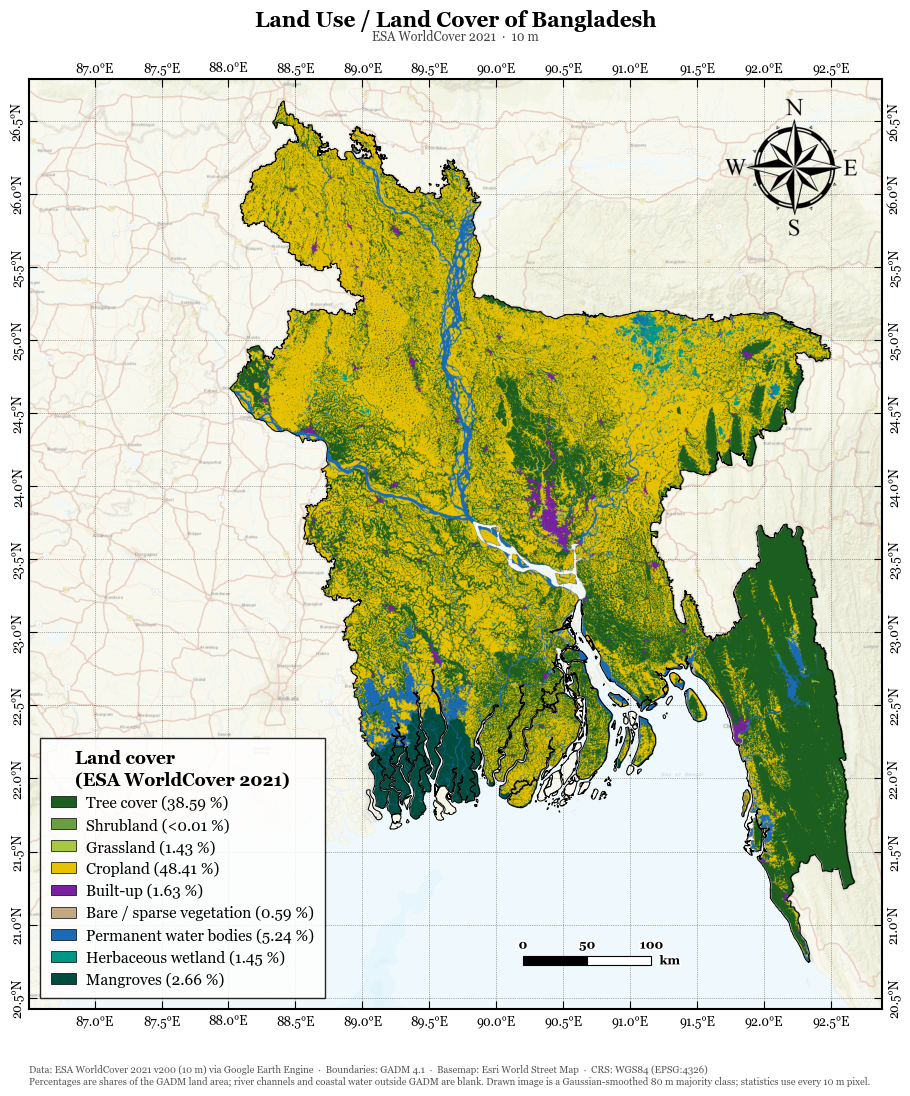

In [8]:
# Cell 6: Map 1 - Bangladesh LULC (Gaussian-smoothed per class, drawn and saved)

# ---------- Settings ----------
SIGMA          = 1.5                  # blur in blocks (1 block = 8 px ~ 80 m); higher = smoother
WEIGHT         = {50: 2.5, 80: 1.8}   # boost so built-up and rivers survive the blur
LEGEND_SCALE   = 1.4                  # legend font = 8 pt x this
NORTH_ARROW_IN = 1.5
BASEMAP_ALPHA, BASEMAP_ZOOM = 0.45, 9
FIG_SIZE = (10.5, 11)
PAD = dict(west=1.5, east=0.20, south=0.30, north=0.15)

# ---------- Blur each class, then pick the winner (only legend colours appear) ----------
best     = np.zeros(frac.shape[1:], np.float32)
best_cls = np.zeros(frac.shape[1:], np.uint8)
for j, k in enumerate(class_ids):
    g = gaussian_filter(frac[j].astype(np.float32), SIGMA) * WEIGHT.get(k, 1.0)
    upd = g > best
    best[upd], best_cls[upd] = g[upd], k
best_cls[~frac.any(axis=0)] = 0                              # keep no-data transparent
bd_extent2 = [left, left + Wn * BLOCK * res, top - Hn * BLOCK * res, top]
print("Draw image:", best_cls.shape)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=FIG_SIZE)
fig.patch.set_facecolor("white")
fig.subplots_adjust(left=0.09, right=0.96, top=0.915, bottom=0.07)

ax.imshow(LUT[best_cls], extent=bd_extent2, origin="upper", interpolation="antialiased", zorder=2)
bangladesh_outline.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.7, zorder=5)

ax.set_xlim(bd_extent2[0] - PAD["west"], bd_extent2[1] + PAD["east"])
ax.set_ylim(bd_extent2[2] - PAD["south"], bd_extent2[3] + PAD["north"])
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldStreetMap, zoom=BASEMAP_ZOOM,
                alpha=BASEMAP_ALPHA, attribution=False, zorder=0)
ax.set_aspect(1 / np.cos(np.radians(23.7)))            # after the basemap
style_map_axis(ax)

ax.set_title("Land Use / Land Cover of Bangladesh", fontsize=15, fontweight="bold", pad=38)
ax.text(0.5, 1.038, "ESA WorldCover 2021  \u00b7  10 m", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=9, color="#444444")

def pct(v):
    p = counts[v] / valid * 100
    return "<0.01" if p < 0.01 else f"{p:.2f}"
handles = [Patch(facecolor=LULC_CLASSES[v][1], edgecolor="black", linewidth=0.5,
                 label=f"{LULC_CLASSES[v][0]} ({pct(v)} %)")
           for v in class_ids if counts[v] > 0]
leg = ax.legend(handles=handles, title="Land cover\n(ESA WorldCover 2021)", loc="lower left",
                fontsize=8 * LEGEND_SCALE, title_fontsize=9 * LEGEND_SCALE,
                frameon=True, framealpha=0.85, edgecolor="black", fancybox=False,
                borderpad=0.7, labelspacing=0.45, handlelength=1.6,
                handletextpad=0.7, borderaxespad=0.7)
leg.get_title().set_fontweight("bold")
leg.set_zorder(20)

add_scale_bar_km(ax, lon0=90.2, lat=ax.get_ylim()[0] + 0.30, total_km=100, n_seg=2)

ia = inset_axes(ax, width=NORTH_ARROW_IN, height=NORTH_ARROW_IN, loc="upper right", borderpad=1.0)
ia.imshow(plt.imread(NORTH_ARROW_FILE), interpolation="hanning")
ia.axis("off")

ax.text(0.0, -0.06,
        "Data: ESA WorldCover 2021 v200 (10 m) via Google Earth Engine  \u00b7  Boundaries: GADM 4.1  \u00b7  "
        "Basemap: Esri World Street Map  \u00b7  CRS: WGS84 (EPSG:4326)\n"
        "Percentages are shares of the GADM land area; river channels and coastal water outside GADM are blank. "
        "Drawn image is a Gaussian-smoothed 80 m majority class; statistics use every 10 m pixel.",
        transform=ax.transAxes, ha="left", va="top", fontsize=7, color="#555555")

out = OUT_DIR / "EC3_Map1_Bangladesh_LULC.png"
fig.savefig(out, dpi=600, facecolor="white", bbox_inches="tight")
print("Saved:", out, "|", round(os.path.getsize(out) / 1e6, 1), "MB")
plt.show()


Figure: 15.3 x 9.9 in
Saved: outputs\EC3_Map2_Dhaka_LULC.png | 13.0 MB


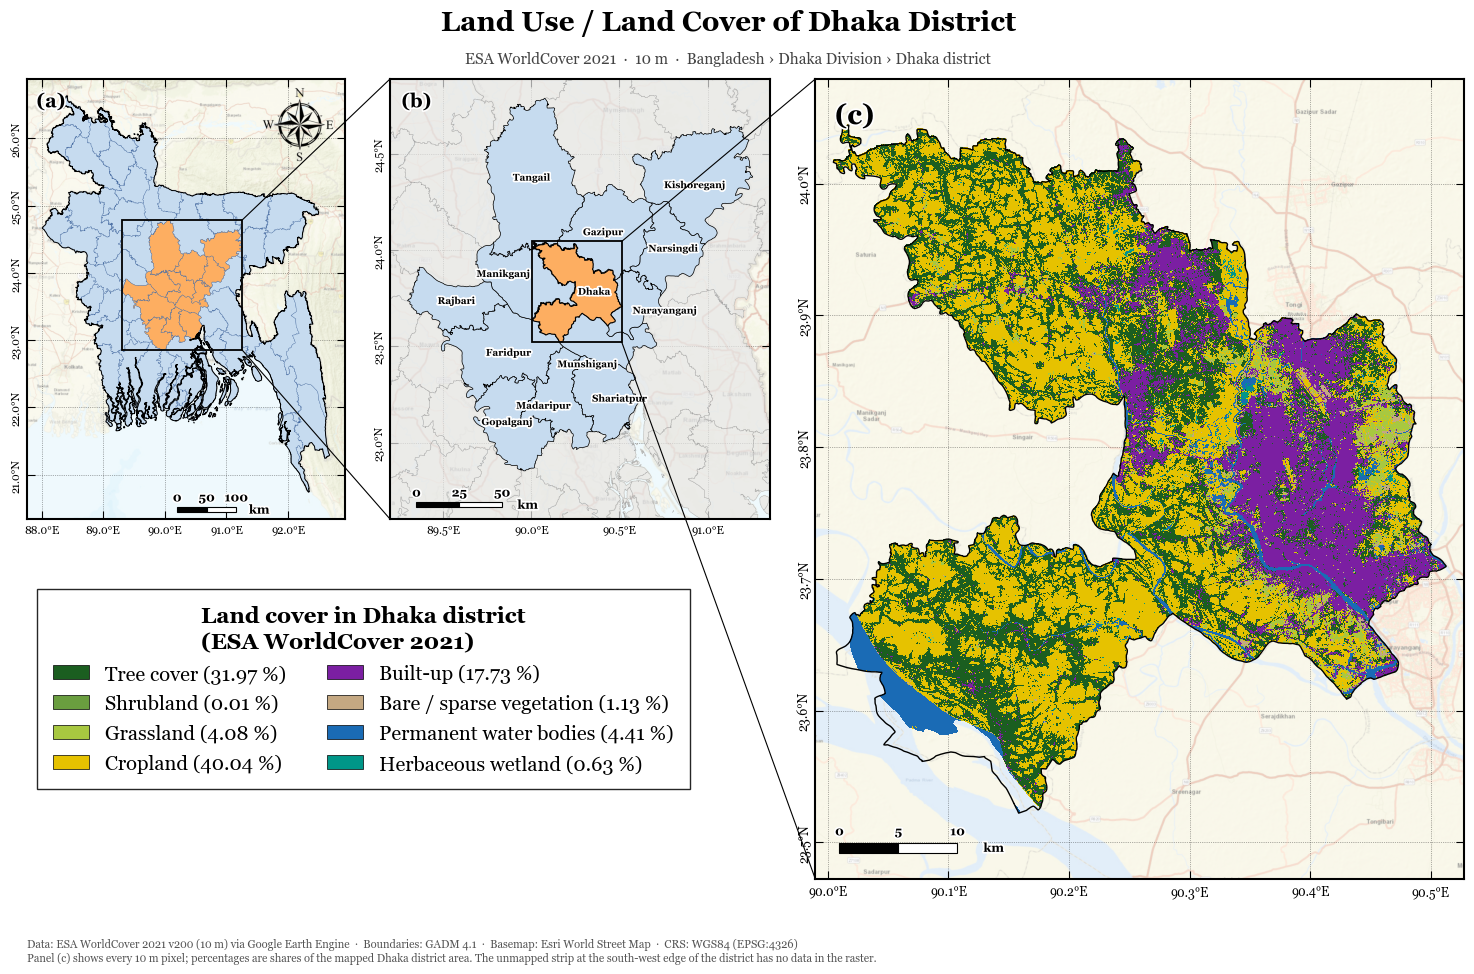

In [9]:
# Cell 7: Map 2 - Bangladesh > Dhaka Division > Dhaka district (3 panels, drawn and saved)
# Needs Cells 1-5 (helpers, boundaries and the Dhaka clip).

# ---------- Settings ----------
BASE_BLUE, HILITE, EDGE = "#c6dbef", "#fdae61", "#4a6fa5"     # EC1/EC2 palette
BASEMAP_ALPHA = 0.45

# ---------- Layout in inches (edit these) ----------
H_C, H_S = 8.0, 0.55 * 8.0                                   # height of panel (c) and of (a)/(b)
GAP, ML, MR, MB, MT = 0.45, 0.65, 0.30, 0.95, 1.00

# (b) label nudges in degrees (dx, dy)
OFFS = {"Manikganj": (-0.10, 0.04), "Narayanganj": (0.14, -0.03),
        "Munshiganj": (-0.12, -0.12), "Madaripur": (-0.06, -0.04), "Shariatpur": (0.08, 0.0)}

# ---------- Panel limits (degrees): west, east, south, north padding ----------
xa, ya = limits(bangladesh_outline,     0.25, 0.25, 0.40, 0.25)
xb, yb = limits(dhaka_division_outline, 0.10, 0.10, 0.25, 0.10)
xc, yc = limits(dhaka_district,         0.015, 0.015, 0.05, 0.035)   # tighter padding = more zoom

ratios = [wh_ratio(xa, ya), wh_ratio(xb, yb), wh_ratio(xc, yc)]
w_a, w_b, w_c = ratios[0] * H_S, ratios[1] * H_S, ratios[2] * H_C
FW = ML + w_a + GAP + w_b + GAP + w_c + MR
FH = MB + H_C + MT
print("Figure:", round(FW, 1), "x", round(FH, 1), "in")

fig = plt.figure(figsize=(FW, FH))
fig.patch.set_facecolor("white")
def pos(x, y, w, h):
    return [x / FW, y / FH, w / FW, h / FH]
y_small = MB + H_C - H_S
ax_a = fig.add_axes(pos(ML, y_small, w_a, H_S))
ax_b = fig.add_axes(pos(ML + w_a + GAP, y_small, w_b, H_S))
ax_c = fig.add_axes(pos(ML + w_a + GAP + w_b + GAP, MB, w_c, H_C))

# (a) Bangladesh, Dhaka Division highlighted
gadm.plot(ax=ax_a, facecolor=BASE_BLUE, edgecolor=EDGE, linewidth=0.25, zorder=2)
dhaka_division.plot(ax=ax_a, facecolor=HILITE, edgecolor=EDGE, linewidth=0.25, zorder=3)
bangladesh_outline.boundary.plot(ax=ax_a, color="black", linewidth=0.7, zorder=4)

# (b) Dhaka Division, Dhaka district highlighted, neighbours in grey
gadm[gadm["NAME_1"] != "Dhaka"].plot(ax=ax_b, facecolor="#e6e6e6", edgecolor="#9a9a9a",
                                     linewidth=0.3, alpha=0.7, zorder=2)
dhaka_division.plot(ax=ax_b, facecolor=BASE_BLUE, edgecolor="black", linewidth=0.5, zorder=3)
dhaka_district.plot(ax=ax_b, facecolor=HILITE, edgecolor="black", linewidth=0.8, zorder=4)
for _, row in dhaka_division.iterrows():
    p = row.geometry.representative_point()
    dx, dy = OFFS.get(row["NAME_2"], (0, 0))
    ax_b.text(p.x + dx, p.y + dy, row["NAME_2"], ha="center", va="center", fontsize=7,
              fontweight="bold", zorder=9, path_effects=halo)

# (c) Dhaka district LULC, every 10 m pixel
ax_c.imshow(LUT[lulc_dhaka], extent=[left_d, right_d, bottom_d, top_d],
            origin="upper", interpolation="nearest", zorder=2)
dhaka_district.boundary.plot(ax=ax_c, color="black", linewidth=1.0, zorder=5)

# Limits -> basemap -> aspect -> style
for ax, xl, yl, zoom, step in [(ax_a, xa, ya, 8, 1.0), (ax_b, xb, yb, 9, 0.5), (ax_c, xc, yc, 12, 0.1)]:
    ax.set_xlim(xl); ax.set_ylim(yl)
    add_basemap(ax, zoom)
    ax.set_aspect(1 / np.cos(np.radians(sum(yl) / 2)))
    style_axis(ax, step)
for ax in (ax_a, ax_b):
    ax.tick_params(labelsize=8)

# Panel labels, scale bars, north arrow
for ax, lab, fs in [(ax_a, "(a)", 14), (ax_b, "(b)", 14), (ax_c, "(c)", 20)]:
    ax.text(0.03, 0.97, lab, transform=ax.transAxes, ha="left", va="top",
            fontsize=fs, fontweight="bold", zorder=12, path_effects=halo)
scale_bar(ax_a, lon0=90.2, lat=ya[0] + 0.10, total_km=100)
scale_bar(ax_b, lon0=xb[0] + 0.15, lat=yb[0] + 0.06, total_km=50)
scale_bar(ax_c, lon0=xc[0] + 0.02, lat=yc[0] + 0.02, total_km=10)
ia = inset_axes(ax_a, width=0.8, height=0.8, loc="upper right", borderpad=0.4)
ia.imshow(plt.imread(NORTH_ARROW_FILE), interpolation="hanning"); ia.axis("off")

# Zoom rectangles + connectors
bd_a = dhaka_division_outline.total_bounds
bd_b = dhaka_district.total_bounds
zoom_box(ax_a, bd_a); zoom_box(ax_b, bd_b)
connect(fig, ax_a, bd_a, ax_b)
connect(fig, ax_b, bd_b, ax_c)

# Legend: only classes present in Dhaka district, % of the mapped district area
cd = np.bincount(lulc_dhaka.ravel(), minlength=256)
vd = cd[1:].sum()
handles = [Patch(facecolor=LULC_CLASSES[v][1], edgecolor="black", linewidth=0.5,
                 label=f"{LULC_CLASSES[v][0]} ({cd[v] / vd * 100:.2f} %)")
           for v in class_ids if cd[v] > 0]
leg = fig.legend(handles=handles, title="Land cover in Dhaka district\n(ESA WorldCover 2021)",
                 loc="upper left", bbox_to_anchor=(ML / FW, (y_small - 0.60) / FH),
                 bbox_transform=fig.transFigure, ncol=2, fontsize=14.5, title_fontsize=16,
                 frameon=True, framealpha=0.85, edgecolor="black", fancybox=False,
                 borderpad=0.8, labelspacing=0.55, handlelength=1.8)
leg.get_title().set_fontweight("bold")

# Title + credits
fig.text(0.5, 1 - 0.30 / FH, "Land Use / Land Cover of Dhaka District", ha="center", va="top",
         fontsize=20, fontweight="bold")
fig.text(0.5, 1 - 0.72 / FH, "ESA WorldCover 2021  \u00b7  10 m  \u00b7  Bangladesh \u203a Dhaka Division \u203a Dhaka district",
         ha="center", va="top", fontsize=11, color="#444444")
fig.text(ML / FW, 0.10 / FH,
         "Data: ESA WorldCover 2021 v200 (10 m) via Google Earth Engine  \u00b7  Boundaries: GADM 4.1  \u00b7  "
         "Basemap: Esri World Street Map  \u00b7  CRS: WGS84 (EPSG:4326)\n"
         "Panel (c) shows every 10 m pixel; percentages are shares of the mapped Dhaka district area. "
         "The unmapped strip at the south-west edge of the district has no data in the raster.",
         ha="left", va="bottom", fontsize=8, color="#555555")

out = OUT_DIR / "EC3_Map2_Dhaka_LULC.png"
fig.savefig(out, dpi=600, facecolor="white", bbox_inches="tight")
print("Saved:", out, "|", round(os.path.getsize(out) / 1e6, 1), "MB")
plt.show()
